# Plot graphs for single trial

In [47]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [155]:
# Specify the directory where the JSON files are stored
directory = './'

# List all JSON files in the directory
json_files = [f for f in os.listdir(directory) if f.endswith('.json')]

json_files = sorted(json_files)

print(json_files)

['logs_20250112_151319.json', 'logs_20250112_173510.json', 'logs_20250112_183052.json']


In [149]:
def get_data_from_json(filename):
    # Load the JSON file
    with open(filename, 'r') as file:
        data = json.load(file)
        return data

# Print the loaded data
# print(data)

filename = json_files[0]
data = get_data_from_json(filename)
# data

In [30]:
print(data.keys())

dict_keys(['control_effort', 'computation_time', 'norm_inputs', 'endpoint_tracking_error', 'drone_position'])


In [55]:
print(np.array(data['control_effort']).shape)
print(np.array(data['computation_time']).shape)
print(np.array(data['norm_inputs']).shape)
print(np.array(data['endpoint_tracking_error']).shape)
print(np.array(data['drone_position']).shape)

(1371,)
(1371,)
(1371, 3)
(5,)
(1371, 3)


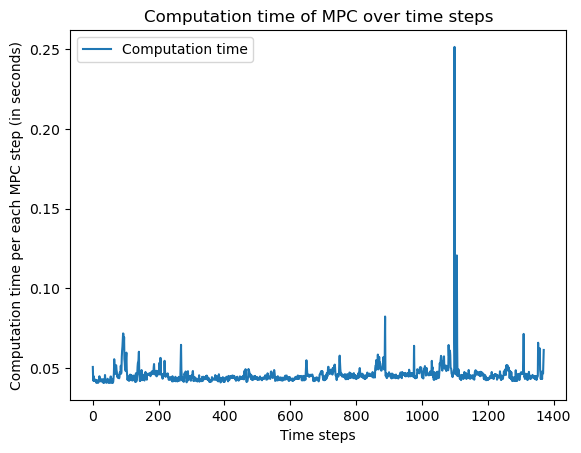

In [54]:
def plot_computation_time(data):
# Create the plot
    plt.plot(data, label='Computation time')

    # Add labels and title
    plt.xlabel('Time steps')
    plt.ylabel('Computation time per each MPC step (in seconds)')
    plt.title('Computation time of MPC over time steps')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

comp_time = data['computation_time']
plot_computation_time(comp_time)

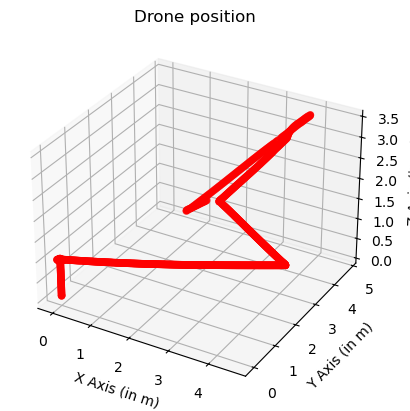

In [59]:
def plot_3d_pos(x,y,z):
    # Create a figure
    fig = plt.figure()

    # Add a 3D subplot
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot
    ax.scatter(x,y,z, c='r', marker='o')

    # Add labels
    ax.set_xlabel('X Axis (in m)')
    ax.set_ylabel('Y Axis (in m)')
    ax.set_zlabel('Z Axis (in m)')
    ax.set_title('Drone position')

    # Show the plot
    plt.show()

x,y,z = np.array(data['drone_position'])[:, 0],np.array(data['drone_position'])[:, 1],np.array(data['drone_position'])[:, 2]
plot_3d_pos(x,y,z)

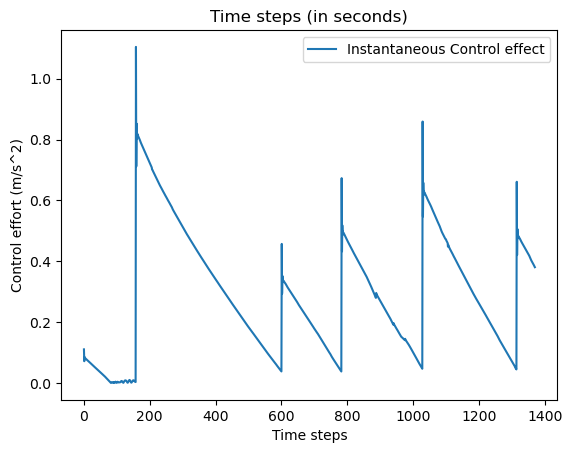

In [64]:
def plot_control_effort(data):
# Create the plot
    plt.plot(data, label='Instantaneous Control effect')

    # Add labels and title
    plt.xlabel('Time steps')
    plt.ylabel('Control effort (m/s^2)')
    plt.title('Time steps (in seconds)')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

contr_eff = data['control_effort']
plot_control_effort(contr_eff)

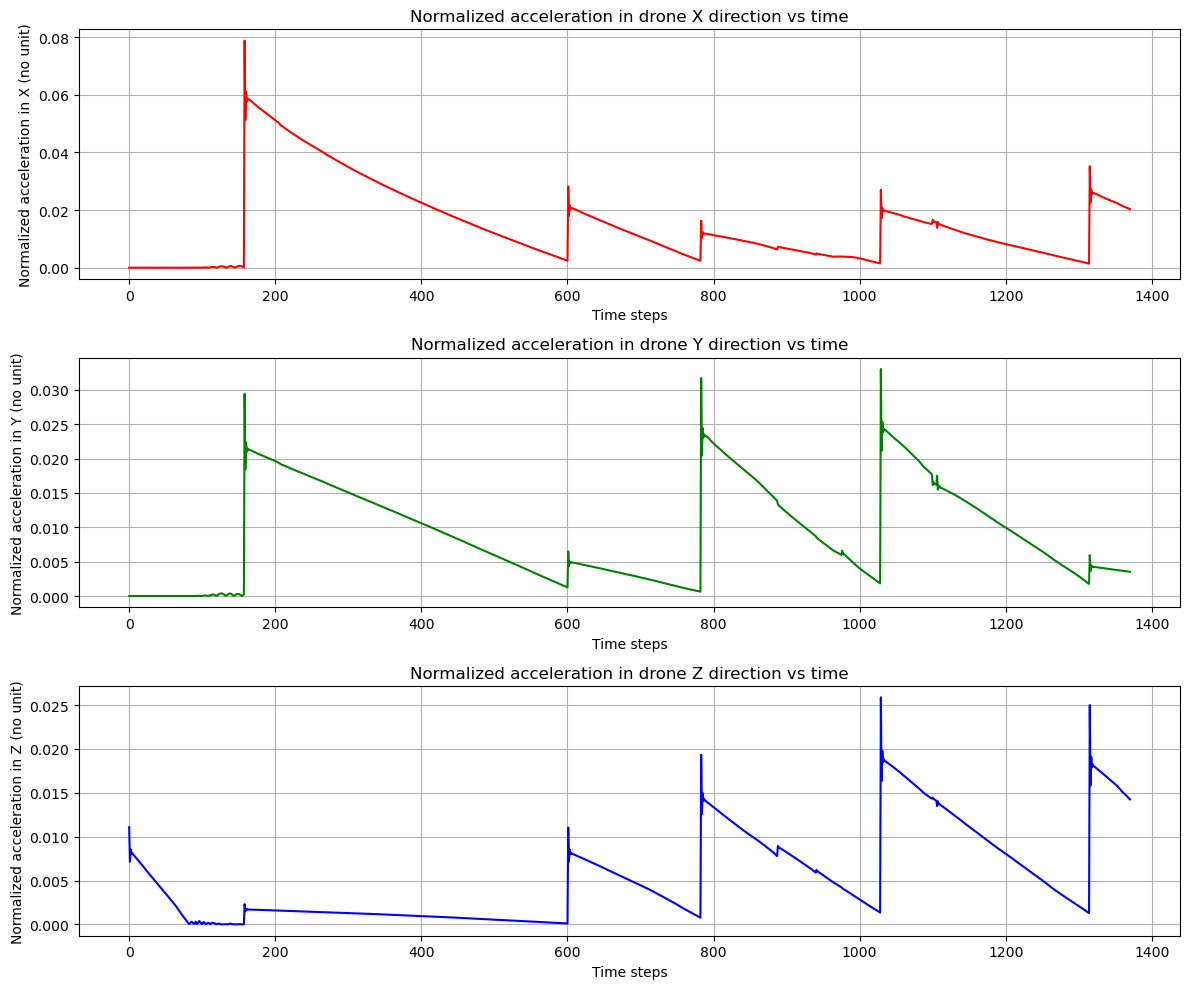

In [81]:
def plot_norm_inputs(x,y,z):
    # Create a figure
    plt.figure(figsize=(12, 10))


    plt.subplot(3, 1, 1)  
    plt.plot(x, color='r')
    plt.title('Normalized acceleration in drone X direction vs time')
    plt.xlabel('Time steps')
    plt.ylabel('Normalized acceleration in X (no unit)')
    plt.grid(True)


    plt.subplot(3, 1, 2)
    plt.plot(y, color='g')
    plt.title('Normalized acceleration in drone Y direction vs time')
    plt.xlabel('Time steps')
    plt.ylabel('Normalized acceleration in Y (no unit)')
    plt.grid(True)


    plt.subplot(3, 1, 3) 
    plt.plot(z, color='b')
    plt.title('Normalized acceleration in drone Z direction vs time')
    plt.xlabel('Time steps')
    plt.ylabel('Normalized acceleration in Z (no unit)')
    plt.grid(True)

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

x_norm, y_norm, z_norm = np.array(data['norm_inputs'])[:, 0],np.array(data['norm_inputs'])[:, 1],np.array(data['norm_inputs'])[:, 2]
plot_norm_inputs(x_norm, y_norm, z_norm)

/tmp/ipykernel_885345/762725641.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


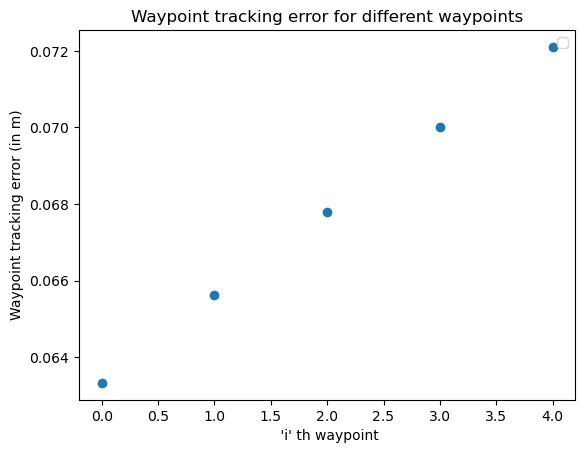

In [ ]:
def plot_waypoint_tracking_error(data):
# Create the plot
    plt.scatter(np.arange(len(data)),data)

    # Add labels and title
    plt.xlabel(""" 'i' th waypoint""")
    plt.ylabel('Waypoint tracking error (in m)')
    plt.title('Waypoint tracking error for different waypoints')

    # Show the plot
    plt.show()

waypoints_trac_error = data['endpoint_tracking_error']
plot_waypoint_tracking_error(waypoints_trac_error)

## Plot instataneous velocity

In [162]:
# def plot_inst_vel(x,y,z):
#     # Create a figure
#     plt.figure(figsize=(12, 10))


#     plt.subplot(3, 1, 1)  
#     plt.plot(x, color='r')
#     plt.title('Instantaneous velocity of drone X direction vs time')
#     plt.xlabel('Time steps')
#     plt.ylabel('Instantaneous velocity X (m/s)')
#     plt.grid(True)


#     plt.subplot(3, 1, 2)
#     plt.plot(y, color='g')
#     plt.title('Instantaneous velocity of drone Y direction vs time')
#     plt.xlabel('Time steps')
#     plt.ylabel('Instantaneous velocity Y (m/s)')
#     plt.grid(True)


#     plt.subplot(3, 1, 3) 
#     plt.plot(z, color='b')
#     plt.title('Instantaneous velocity of drone Z direction vs time')
#     plt.xlabel('Time steps')
#     plt.ylabel('Instantaneous velocity Z (m/s)')
#     plt.grid(True)

#     # Adjust layout for better spacing
#     plt.tight_layout()

#     # Show the plot
#     plt.show()

# x_norm, y_norm, z_norm = np.array(data['inst_velocity'])[:, 0],np.array(data['inst_velocity'])[:, 1],np.array(data['inst_velocity'])[:, 2]
# plot_inst_vel(x_norm, y_norm, z_norm)

In [161]:
np.array(data['inst_velocity']).shape

(594,)

/tmp/ipykernel_885345/3214340100.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


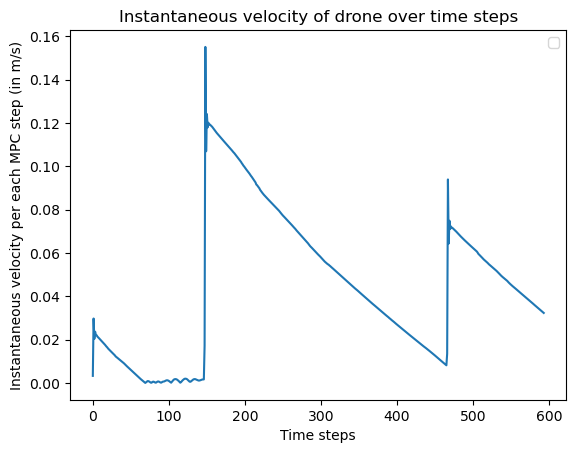

In [163]:
def plot_inst_vel(data):
# Create the plot
    plt.plot(data)

    # Add labels and title
    plt.xlabel('Time steps')
    plt.ylabel('Instantaneous velocity per each MPC step (in m/s)')
    plt.title('Instantaneous velocity of drone over time steps')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

inst_velocity = data['inst_velocity']
plot_inst_vel(inst_velocity)

# Group Analysis (for n trials)

In [111]:
# Specify the directory where the JSON files are stored
directory = './'

# List all JSON files in the directory
json_files = [f for f in os.listdir(directory) if f.endswith('.json')]

json_files = sorted(json_files)
print(json_files)

['logs_20250112_151319.json', 'logs_20250112_173510.json']


In [132]:
trial1 = get_data_from_json(json_files[0])
trial2 = get_data_from_json(json_files[1])

## Computation time

In [ ]:
def get_mean_computation_time(log_files):
    mean_computation_time = []
    for i in range(len(log_files)):
        ith_trial = get_data_from_json(json_files[i])
        mean_computation_time.append(np.sum(ith_trial['computation_time']))
    return mean_computation_time

computation_time_list = get_mean_computation_time(json_files)
print(computation_time_list)

std_computation_time = np.std(computation_time_list)
print(std_computation_time) # standard deviation of computation time for a scenario across different trials

[62.61567681108136, 41.61012316332199]
10.502776823879685


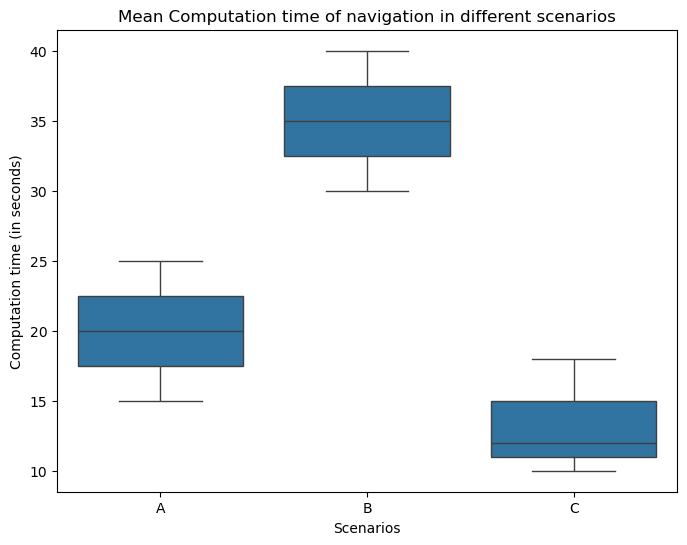

In [ ]:
computation_time_group = {
    'scenarios': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'computation_time': [15, 20, 25, 30, 35, 40, 10, 12, 18]
}

# Create a DataFrame
df = pd.DataFrame(computation_time_group)

# Create the box plot (quartile plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='scenarios', y='computation_time', data=df)

# Add labels and title
plt.title('Mean computation time of navigation in different scenarios')
plt.xlabel('Scenarios')
plt.ylabel('Computation time (in seconds)')

# Show the plot
plt.show()


## Control effort

In [146]:
def get_mean_control_effort(log_files):
    mean_control_effort = []
    for i in range(len(log_files)):
        ith_trial = get_data_from_json(json_files[i])
        mean_control_effort.append(np.sum(ith_trial['control_effort']))
    return mean_control_effort

get_mean_control_effort(json_files)


control_effort_list = get_mean_control_effort(json_files)
print(control_effort_list)

std_control_effort = np.std(control_effort_list)
print(std_control_effort) # standard deviation of control efforts for a scenario across different trials

[396.86741580476667, 220.14371960367748]
88.36184810054459


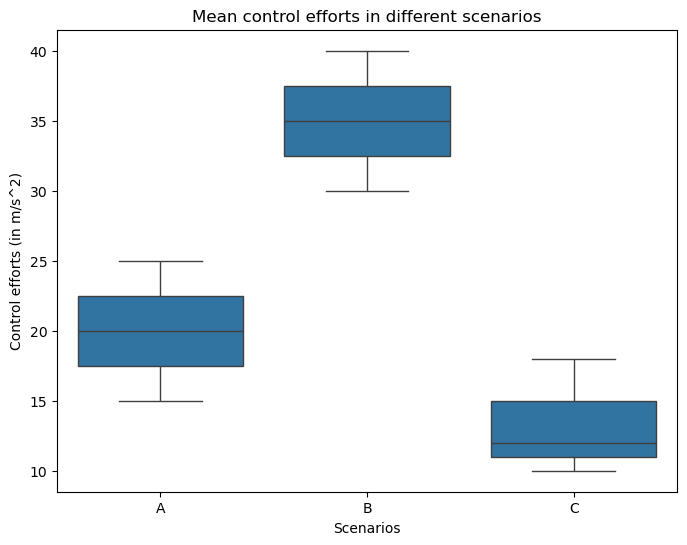

In [144]:
control_effort_group = {
    'scenarios': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'control_effort': [15, 20, 25, 30, 35, 40, 10, 12, 18]
}

# Create a DataFrame
df = pd.DataFrame(control_effort_group)

# Create the box plot (quartile plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='scenarios', y='control_effort', data=df)

# Add labels and title
plt.title('Mean control efforts in different scenarios')
plt.xlabel('Scenarios')
plt.ylabel('Control efforts (in m/s^2)')

# Show the plot
plt.show()

## Waypoint tracking error

In [150]:
# trial1 = 
# trial2 =
# mean_waypoint_error_scenario = mean([train1, train2]) 

waypoints_trac_error_list = data['endpoint_tracking_error'] # mean_waypoint_error_scenario
print(waypoints_trac_error_list)

std_waypoints_trac_error = np.std(waypoints_trac_error_list)
print(std_waypoints_trac_error) # standard deviation of waypoint tracking error for a scenario across different trials

[0.06332564950491067, 0.06562393363561288, 0.06779474165495532, 0.07001801032492111, 0.07210156030946002]
0.0031040100138978806


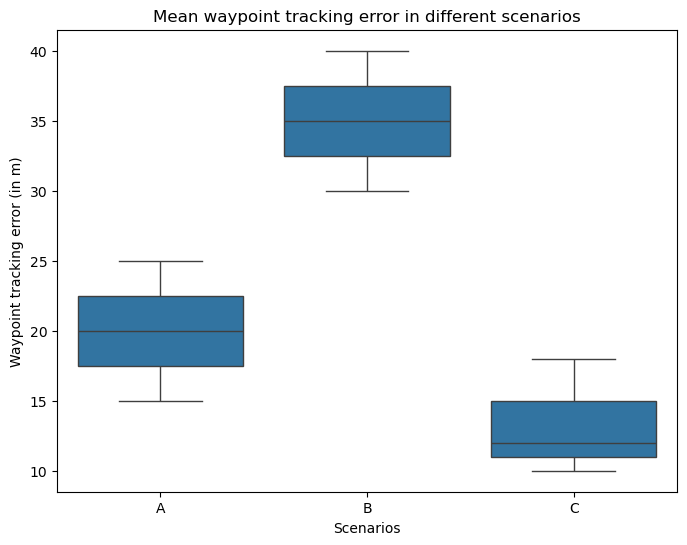

In [151]:
waypoints_trac_error_group = {
    'scenarios': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'waypoints_trac_error': [15, 20, 25, 30, 35, 40, 10, 12, 18]
}

# Create a DataFrame
df = pd.DataFrame(waypoints_trac_error_group)

# Create the box plot (quartile plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='scenarios', y='waypoints_trac_error', data=df)

# Add labels and title
plt.title('Mean waypoint tracking error in different scenarios')
plt.xlabel('Scenarios')
plt.ylabel('Waypoint tracking error (in m)')

# Show the plot
plt.show()

# Mean velocity

In [157]:
data = get_data_from_json(json_files[-1])
data['inst_velocity']

In [ ]:
def get_mean_velocity(log_files):
    mean_velocity = []
    for i in range(len(log_files)):
        ith_trial = get_data_from_json(json_files[i])
        mean_velocity.append(np.sum(ith_trial['inst_velocity']))
    return mean_velocity

mean_velocity_list = get_mean_velocity(json_files)
print(mean_velocity_list)

std_mean_velocity = np.std(mean_velocity_list)
print(std_mean_velocity) # standard deviation of velocity for a scenario across different trials

# Input boundedness